<a href="https://colab.research.google.com/github/Chathuranga630/sionna/blob/main/sk_learn_advance_use_case_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset created successfully
Dataset size: (2000, 8)

First 10 records:


,Customer_ID,Monthly_Charge_LKR,Data_Usage_GB,Complaints,Satisfaction_Score,Tenure_Months,Competitor_Offer,Churn
0,SL001,1360,5,0,1,21,0,0
1,SL002,4272,5,4,1,17,1,1
2,SL003,3592,30,3,3,23,0,0
3,SL004,966,32,0,3,57,1,0
4,SL005,4926,8,0,3,43,0,0
5,SL006,3944,10,5,5,17,0,1
6,SL007,3671,38,4,3,58,0,0
7,SL008,3419,47,2,2,14,0,0
8,SL009,630,32,1,1,29,1,0
9,SL010,2185,48,2,5,20,1,0



Churn distribution:
Churn
0    1146
1     854
Name: count, dtype: int64

Churn percentage:
Churn
0    57.3
1    42.7
Name: proportion, dtype: float64

Training records: 1600
Testing records: 400

Model trained successfully

Model accuracy: 0.92

Classification report:
              precision    recall  f1-score   support

        Stay       0.95      0.91      0.93       229
       Churn       0.89      0.93      0.91       171

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400



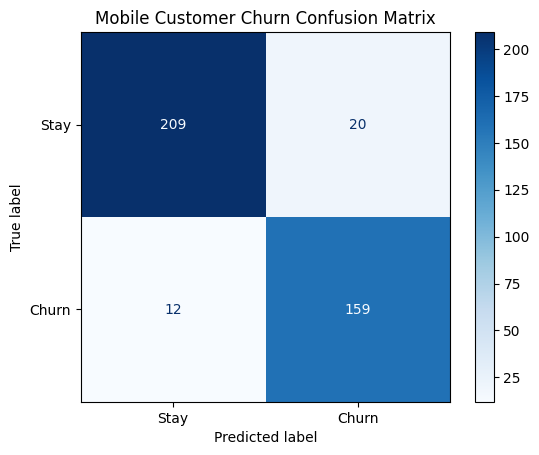

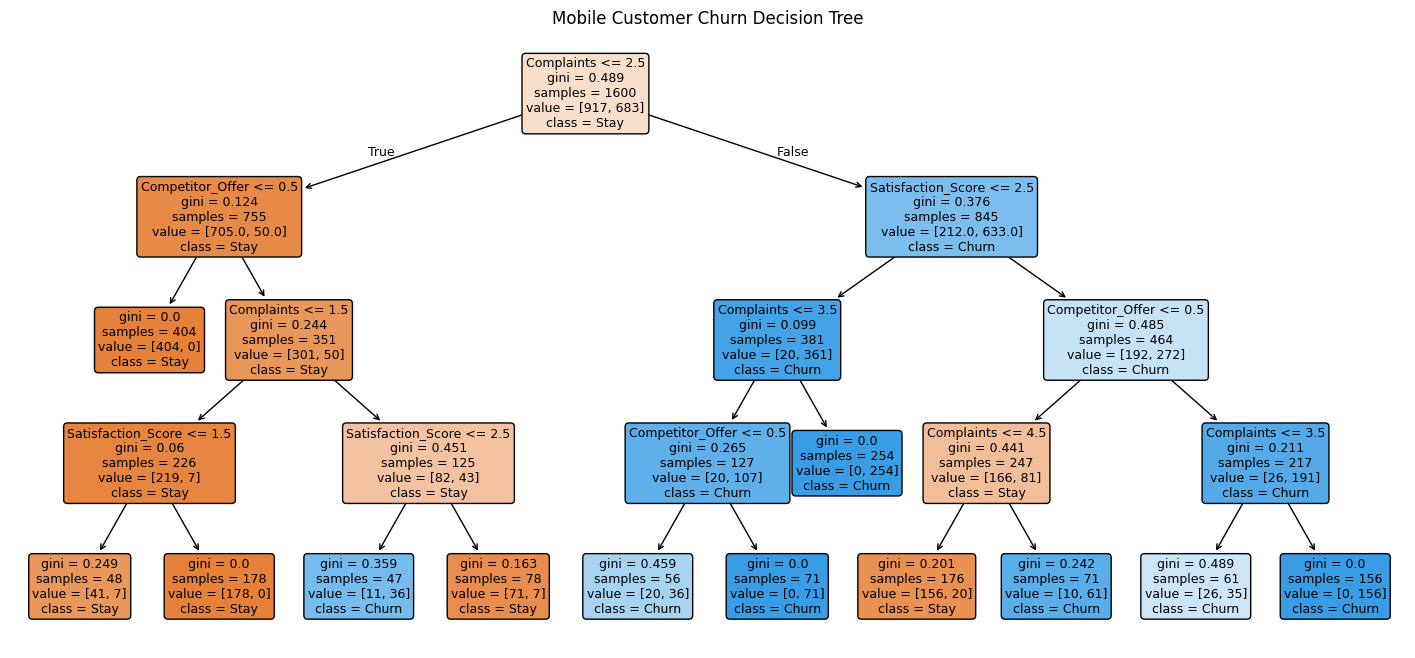


New customer details:


,Monthly_Charge_LKR,Data_Usage_GB,Complaints,Satisfaction_Score,Tenure_Months,Competitor_Offer
0,3500,20,4,2,6,1


Prediction: Customer may leave the mobile service
Estimated churn probability: 100.00%

CSV file created: sri_lanka_mobile_churn_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =====================================================
# BASIC MOBILE CUSTOMER CHURN CLASSIFICATION
# Sri Lanka
# =====================================================

# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from google.colab import files


# =====================================================
# 2. Generate a synthetic customer dataset
# =====================================================

np.random.seed(42)

number_of_customers = 2000

data = pd.DataFrame({
    "Customer_ID": [
        f"SL{number:03d}"
        for number in range(1, number_of_customers + 1)
    ],

    "Monthly_Charge_LKR": np.random.randint(
        500, 5000, number_of_customers
    ),

    "Data_Usage_GB": np.random.randint(
        1, 50, number_of_customers
    ),

    "Complaints": np.random.randint(
        0, 6, number_of_customers
    ),

    "Satisfaction_Score": np.random.randint(
        1, 6, number_of_customers
    ),

    "Tenure_Months": np.random.randint(
        1, 61, number_of_customers
    ),

    # 0 = No competitor offer, 1 = Received competitor offer
    "Competitor_Offer": np.random.choice(
        [0, 1], number_of_customers
    )
})


# =====================================================
# 3. Create the churn target
# =====================================================

churn_score = (
    data["Complaints"] * 2
    + data["Competitor_Offer"] * 3
    - data["Satisfaction_Score"]
    - data["Tenure_Months"] / 20
)

# 0 = Stay, 1 = Churn
data["Churn"] = np.where(
    churn_score > 3,
    1,
    0
)

print("Dataset created successfully")
print("Dataset size:", data.shape)

print("\nFirst 10 records:")
display(data.head(10))

print("\nChurn distribution:")
print(data["Churn"].value_counts())

print("\nChurn percentage:")
print(
    data["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# =====================================================
# 4. Select input features and target
# =====================================================

X = data[[
    "Monthly_Charge_LKR",
    "Data_Usage_GB",
    "Complaints",
    "Satisfaction_Score",
    "Tenure_Months",
    "Competitor_Offer"
]]

y = data["Churn"]


# =====================================================
# 5. Divide data into training and testing sets
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining records:", len(X_train))
print("Testing records:", len(X_test))


# =====================================================
# 6. Create and train the classification model
# =====================================================

model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel trained successfully")


# =====================================================
# 7. Make predictions
# =====================================================

predictions = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("\nModel accuracy:", round(accuracy, 2))

print("\nClassification report:")
print(
    classification_report(
        y_test,
        predictions,
        target_names=["Stay", "Churn"]
    )
)


# =====================================================
# 8. Display confusion matrix
# =====================================================

matrix = confusion_matrix(
    y_test,
    predictions
)

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=["Stay", "Churn"]
)

display_matrix.plot(
    cmap="Blues"
)

plt.title("Mobile Customer Churn Confusion Matrix")
plt.show()


# =====================================================
# 9. Display the decision tree
# =====================================================

plt.figure(figsize=(18, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Stay", "Churn"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Mobile Customer Churn Decision Tree")
plt.show()


# =====================================================
# 10. Predict churn for a new customer
# =====================================================

new_customer = pd.DataFrame({
    "Monthly_Charge_LKR": [3500],
    "Data_Usage_GB": [20],
    "Complaints": [4],
    "Satisfaction_Score": [2],
    "Tenure_Months": [6],
    "Competitor_Offer": [1]
})

new_prediction = model.predict(
    new_customer
)[0]

churn_probability = model.predict_proba(
    new_customer
)[0][1]

print("\nNew customer details:")
display(new_customer)

if new_prediction == 1:
    print("Prediction: Customer may leave the mobile service")
else:
    print("Prediction: Customer will probably stay")

print(
    "Estimated churn probability:",
    f"{churn_probability:.2%}"
)


# =====================================================
# 11. Save and download the CSV dataset
# =====================================================

csv_filename = "sri_lanka_mobile_churn_dataset.csv"

data.to_csv(
    csv_filename,
    index=False
)

print("\nCSV file created:", csv_filename)

files.download(csv_filename)

In [ ]:
# =====================================================
# 12. Export and download the trained model
# =====================================================

import joblib

# Store the model and required feature names together
model_package = {
    "model": model,
    "feature_columns": X.columns.tolist(),
    "class_names": {
        0: "Stay",
        1: "Churn"
    }
}

model_filename = "mobile_churn_model.pkl"

# Export the model
joblib.dump(
    model_package,
    model_filename
)

print("Model exported successfully:", model_filename)

# Download the model
files.download(model_filename)


# =====================================================
# 13. Test the exported model
# =====================================================

loaded_package = joblib.load(
    model_filename
)

loaded_model = loaded_package["model"]
feature_columns = loaded_package["feature_columns"]

test_customer = pd.DataFrame({
    "Monthly_Charge_LKR": [3500],
    "Data_Usage_GB": [20],
    "Complaints": [4],
    "Satisfaction_Score": [2],
    "Tenure_Months": [6],
    "Competitor_Offer": [1]
})

# Ensure the correct feature order
test_customer = test_customer[feature_columns]

loaded_prediction = loaded_model.predict(
    test_customer
)[0]

loaded_probability = loaded_model.predict_proba(
    test_customer
)[0][1]

if loaded_prediction == 1:
    result = "Customer may leave"
else:
    result = "Customer will probably stay"

print("\nLoaded model prediction:", result)
print(
    "Churn probability:",
    f"{loaded_probability:.2%}"
)

Model exported successfully: mobile_churn_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Loaded model prediction: Customer may leave
Churn probability: 100.00%
